### 1. Chargement des données brutes  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = Path('../data/raw/heart_disease_uci.csv')
PROC_PATH = Path('../data/processed')
FIGS_PATH = Path('../reports/figures')

# Colonnes par type
NUM_COLS = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'chol_per_age', 'thalch_ratio']
BIN_COLS = ['fbs', 'exang', 'ca_missing', 'thal_missing']
OHE_COLS = ['cp', 'thal', 'dataset']
LBL_COLS = ['sex', 'restecg', 'slope']
TARGET   = 'num'

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['id'])
print(f'Données chargées : {df.shape[0]} lignes × {df.shape[1]} colonnes')

Données chargées : 920 lignes × 15 colonnes


### 2 — Nettoyage des valeurs aberrantes

Corrections appliquées :
  chol = 0     → NaN : 172 valeurs
  trestbps = 0 → NaN : 1 valeur
  oldpeak < 0  → 0   : 12 valeurs


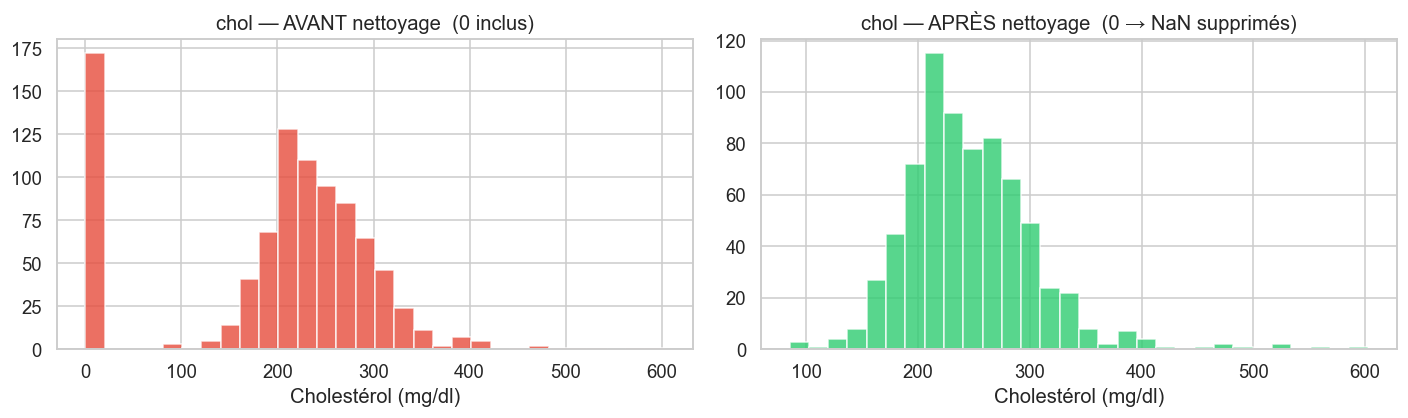

In [2]:
df_before = df.copy()

# chol = 0 → NaN
n_chol = (df['chol'] == 0).sum()
df.loc[df['chol'] == 0, 'chol'] = np.nan

# trestbps = 0 → NaN
n_bps = (df['trestbps'] == 0).sum()
df.loc[df['trestbps'] == 0, 'trestbps'] = np.nan

# oldpeak < 0 → 0
n_old = (df['oldpeak'] < 0).sum()
df.loc[df['oldpeak'] < 0, 'oldpeak'] = 0.0

print(f'Corrections appliquées :')
print(f'  chol = 0     → NaN : {n_chol} valeurs')
print(f'  trestbps = 0 → NaN : {n_bps} valeur')
print(f'  oldpeak < 0  → 0   : {n_old} valeurs')

# Visualisation avant/après pour chol
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_before['chol'].dropna(), bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('chol — AVANT nettoyage  (0 inclus)')
axes[0].set_xlabel('Cholestérol (mg/dl)')
axes[1].hist(df['chol'].dropna(), bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('chol — APRÈS nettoyage  (0 → NaN supprimés)')
axes[1].set_xlabel('Cholestérol (mg/dl)')
plt.tight_layout()
plt.savefig(FIGS_PATH / '08_chol_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

### 3 — Binarisation de la cible + typage des booléens

In [ ]:
print(f'Distribution cible brute : {dict(df[TARGET].value_counts().sort_index())}')  # distribution avant transformation

# Binarisation : 0 = sain, 1 = malade
df[TARGET] = (df[TARGET] > 0).astype(int)  # conversion en problème binaire
print(f'Distribution cible binaire : {dict(df[TARGET].value_counts().sort_index())}')  # distribution après binarisation

# fbs / exang : True/False → 0/1
for col in ['fbs', 'exang']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})  # encodage binaire
    print(f'{col} → dtype après cast : {df[col].dtype}  |  manquants : {df[col].isna().sum()}')  # vérification

Distribution cible brute : {0: np.int64(411), 1: np.int64(265), 2: np.int64(109), 3: np.int64(107), 4: np.int64(28)}
Distribution cible binaire : {0: np.int64(411), 1: np.int64(509)}
fbs → dtype après cast : float64  |  manquants : 90
exang → dtype après cast : float64  |  manquants : 55


### 4 — Feature Engineering

ca_missing   : 611 patients sans ca (66.4%)
thal_missing : 486 patients sans thal (52.8%)

chol_per_age  — min=1.52  max=16.53  mean=4.81
thalch_ratio  — min=0.355  max=1.175  mean=0.824


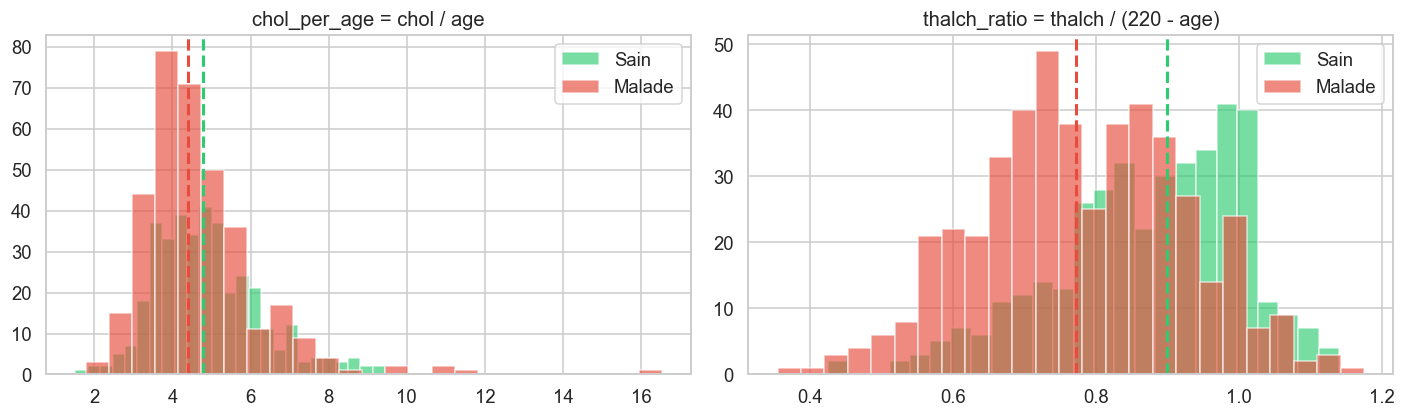

In [4]:
# Flags manque AVANT imputation (sinon perte d'information)
df['ca_missing']   = df['ca'].isna().astype(int)
df['thal_missing'] = df['thal'].isna().astype(int)

print(f'ca_missing   : {df["ca_missing"].sum()} patients sans ca ({df["ca_missing"].mean():.1%})')
print(f'thal_missing : {df["thal_missing"].sum()} patients sans thal ({df["thal_missing"].mean():.1%})')

# Features dérivées cliniques
df['chol_per_age'] = df['chol'] / df['age']
df['thalch_ratio'] = df['thalch'] / (220 - df['age']).clip(lower=1)

print(f'\nchol_per_age  — min={df["chol_per_age"].min():.2f}  max={df["chol_per_age"].max():.2f}  mean={df["chol_per_age"].mean():.2f}')
print(f'thalch_ratio  — min={df["thalch_ratio"].min():.3f}  max={df["thalch_ratio"].max():.3f}  mean={df["thalch_ratio"].mean():.3f}')

# Visualisation des nouvelles features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in [
    (axes[0], 'chol_per_age', 'chol_per_age = chol / age'),
    (axes[1], 'thalch_ratio', 'thalch_ratio = thalch / (220 - age)')
]:
    for val, label, color in [(0,'Sain','#2ecc71'), (1,'Malade','#e74c3c')]:
        subset = df[df[TARGET] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
        ax.axvline(subset.median(), color=color, linestyle='--', linewidth=2)  # médiane
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_PATH / '09_new_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 5 — Train / Test split (stratifié, sans data leakage)